In [7]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image
import random

## state_schema

In [8]:
class AgentState(TypedDict):
    player_name: str
    gusses: List[int]
    attempts: int
    upper_bound: int
    lower_bound: int
    actual_number: int
    number_of_gusses: int

## Create nodes

In [75]:
def setup(state: AgentState) -> AgentState:
    """To intialize values"""

    state['actual_number'] = 8
    state['number_of_gusses'] = 7
    state['attempts'] = 0
    state['lower_bound'] = 1
    state['upper_bound'] = 20

    return state

def guess(state: AgentState) -> AgentState:
    """Guess the random number"""

    state['gusses'].append(random.randint(state['lower_bound'], state['upper_bound']))
    state['attempts'] += 1

    return state

def check_and_updates(state: AgentState) -> AgentState:
    """Update bounds on the basis of guess"""

    gussed_number = state['gusses'][-1]

    if gussed_number < state['actual_number']:

        state['lower_bound'] = gussed_number

    elif gussed_number > state['actual_number']:

        state['upper_bound'] = gussed_number

    return state
    

def check_number(state: AgentState):
    """Check if gussed number is correct"""

    if len(state['gusses']) >= state['number_of_gusses']:

        return True

    gussed_number = state['gusses'][-1]

    if state['actual_number'] == gussed_number:

        print("Number gussed")

        return True
    else:

        return False


## Create Graph

In [76]:
graph = StateGraph(AgentState)


graph.add_node("setup", setup)
graph.add_node("guess", guess)
graph.add_node("check_and_updates", check_and_updates)

graph.add_edge(START, "setup")
graph.add_edge("setup", "guess")
graph.add_edge("guess", "check_and_updates")


graph.add_conditional_edges(
    "check_and_updates",
    check_number,

    {
        True: END,
        False: "guess"
    }
)

app = graph.compile()

## Draw graph

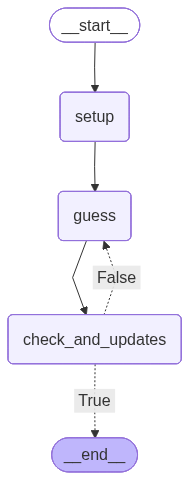

In [61]:
display(Image(app.get_graph().draw_mermaid_png()))

## Invoke

In [77]:
response = app.invoke(AgentState(player_name="Bakar", gusses=[]))

Number gussed


In [78]:
response

{'player_name': 'Bakar',
 'gusses': [4, 10, 4, 8],
 'attempts': 4,
 'upper_bound': 10,
 'lower_bound': 4,
 'actual_number': 8,
 'number_of_gusses': 7}